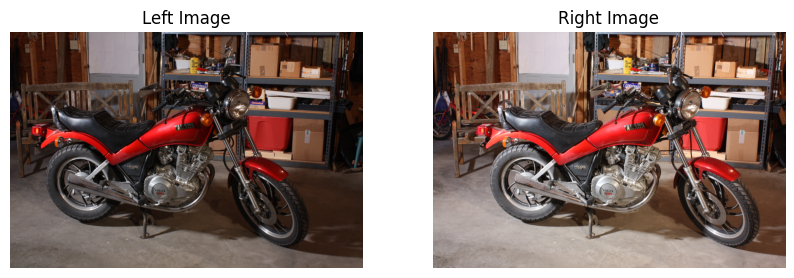

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

left_img = cv2.imread("data/left.png")
right_img = cv2.imread("data/right.png")

left_rgb = cv2.cvtColor(left_img, cv2.COLOR_BGR2RGB)
right_rgb = cv2.cvtColor(right_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(left_rgb)
plt.title("Left Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(right_rgb)
plt.title("Right Image")
plt.axis("off")

plt.show()

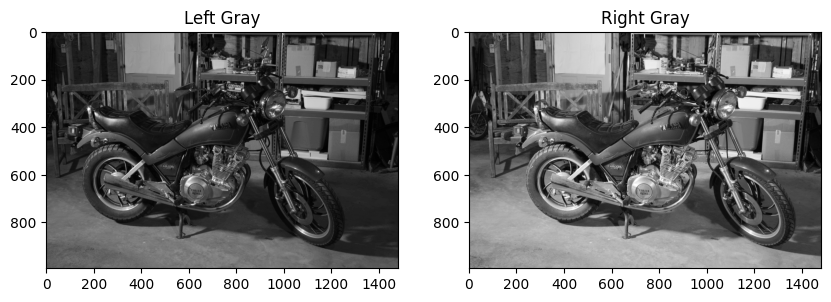

In [2]:
left_gray = cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY)
right_gray = cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(left_gray, cmap="gray")
plt.title("Left Gray")

plt.subplot(1,2,2)
plt.imshow(right_gray, cmap="gray")
plt.title("Right Gray")

plt.show()

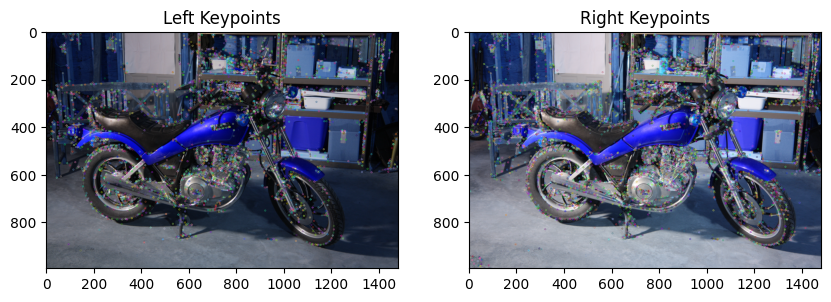

Left keypoints: 4761
Right keypoints: 6785


In [3]:
sift = cv2.SIFT_create()

kp_left, des_left = sift.detectAndCompute(left_gray, None)
kp_right, des_right = sift.detectAndCompute(right_gray, None)

img1 = cv2.drawKeypoints(left_img, kp_left, None)
img2 = cv2.drawKeypoints(right_img, kp_right, None)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("Left Keypoints")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("Right Keypoints")

plt.show()

print("Left keypoints:", len(kp_left))
print("Right keypoints:", len(kp_right))

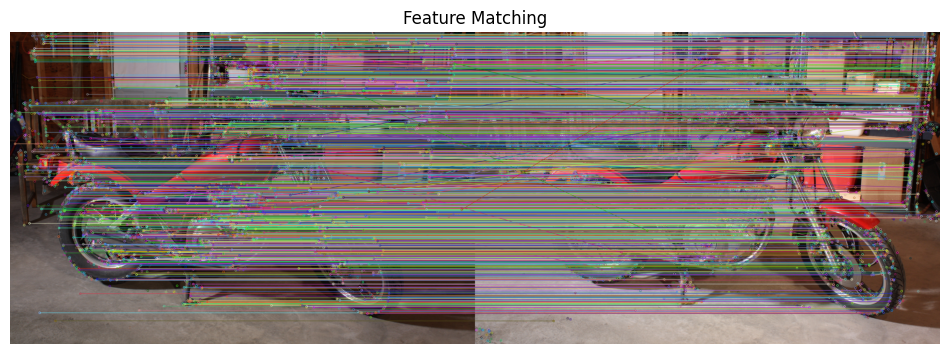

Good matches: 1642


In [4]:
bf = cv2.BFMatcher(cv2.NORM_L2)

matches = bf.knnMatch(des_left, des_right, k=2)

good = []
ratio = 0.75

for m, n in matches:
    if m.distance < ratio * n.distance:
        good.append(m)

matched_img = cv2.drawMatches(
    left_rgb, kp_left,
    right_rgb, kp_right,
    good, None
)

plt.figure(figsize=(12,6))
plt.imshow(matched_img)
plt.title("Feature Matching")
plt.axis("off")
plt.show()

print("Good matches:", len(good))

In [5]:
pts_left = np.float32([kp_left[m.queryIdx].pt for m in good])
pts_right = np.float32([kp_right[m.trainIdx].pt for m in good])

F, mask = cv2.findFundamentalMat(
    pts_left,
    pts_right,
    cv2.FM_RANSAC,
    1.0,
    0.99
)

print("Fundamental Matrix:\n", F)
print("Shape:", F.shape)

Fundamental Matrix:
 [[ 1.58921773e-08  3.79732523e-05 -2.07679113e-02]
 [-3.76817105e-05 -2.75852261e-06  3.32709725e-01]
 [ 2.04745246e-02 -3.33127698e-01  1.00000000e+00]]
Shape: (3, 3)


In [9]:
pts_left_in = pts_left[mask.ravel() == 1]
pts_right_in = pts_right[mask.ravel() == 1]

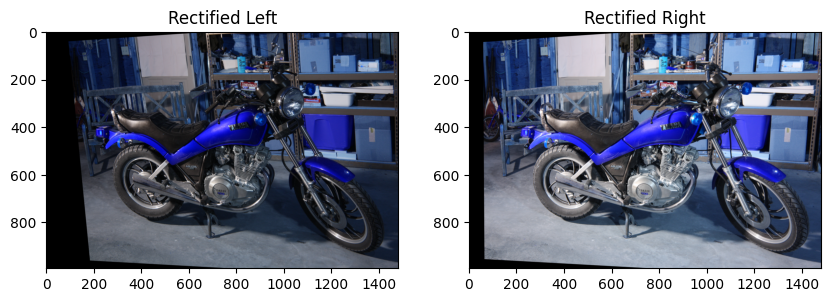

In [10]:
h, w = left_gray.shape

_, H1, H2 = cv2.stereoRectifyUncalibrated(
    pts_left_in,
    pts_right_in,
    F,
    imgSize=(w, h)
)

rect_left = cv2.warpPerspective(left_img, H1, (w, h))
rect_right = cv2.warpPerspective(right_img, H2, (w, h))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(rect_left)
plt.title("Rectified Left")

plt.subplot(1,2,2)
plt.imshow(rect_right)
plt.title("Rectified Right")

plt.show()

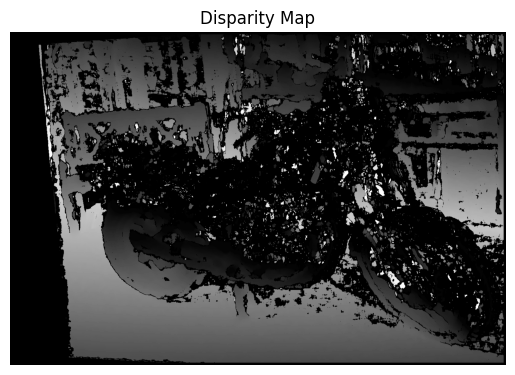

In [11]:
rect_left_gray = cv2.cvtColor(rect_left, cv2.COLOR_BGR2GRAY)
rect_right_gray = cv2.cvtColor(rect_right, cv2.COLOR_BGR2GRAY)

stereo = cv2.StereoBM_create(numDisparities=64, blockSize=15)

disparity = stereo.compute(rect_left_gray, rect_right_gray)

disp_vis = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX)
disp_vis = np.uint8(disp_vis)

plt.imshow(disp_vis, cmap="gray")
plt.title("Disparity Map")
plt.axis("off")
plt.show()

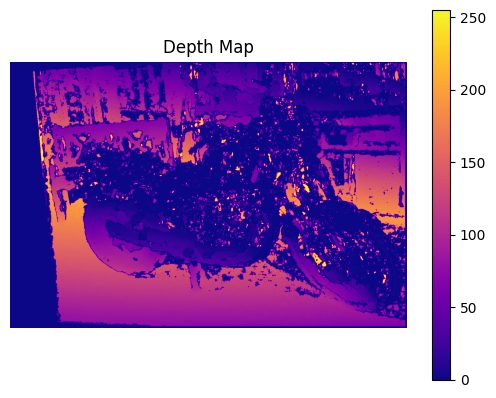

In [12]:
plt.imshow(disp_vis, cmap="plasma")
plt.colorbar()
plt.title("Depth Map")
plt.axis("off")
plt.show()